# Differential Privacy: Insurance Dataset

## 1) Introduction: Privacy–Utility Trade-off
This notebook studies the privacy–utility trade-off for a binary classifier predicting **smoker** status from the insurance dataset. We compare baseline models (SVM and decision tree) with feature-level differential privacy (DP) noise mechanisms and a DP-SGD neural network. **ROC-AUC** is the primary metric used throughout.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

from dp.constants import RANDOM_STATE
from dp.dpsgd import opacus_available
from dp.fairness import demographic_parity_difference, equalized_odds_difference
from dp.models import build_decision_tree_model, build_svm_model
from dp.pipeline import apply_bounded_feature_noise, build_preprocessor, clip_numeric, split_dataset

np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8")

## 2) Dataset overview + class imbalance

In [2]:
repo_root = Path("..").resolve()
data_path = repo_root / "data" / "insurance.csv"

df = pd.read_csv(data_path)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


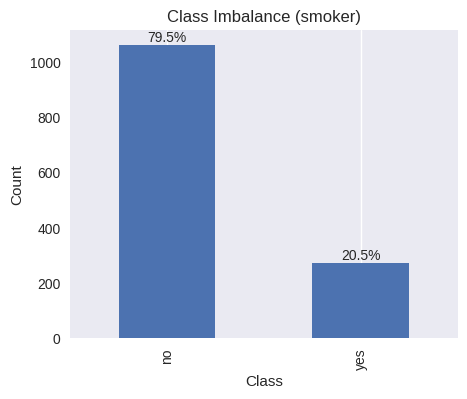

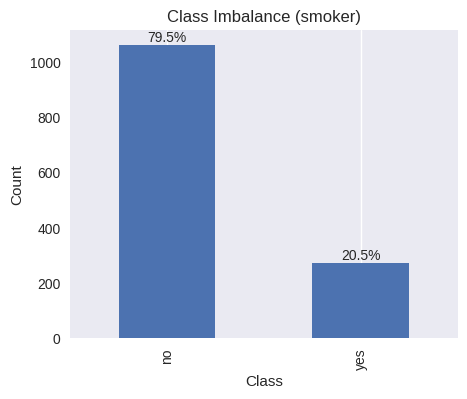

In [4]:
class_counts = df["smoker"].value_counts()
class_props = class_counts / class_counts.sum()

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Class Imbalance (smoker)")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
for idx, value in enumerate(class_counts.values):
    ax.text(idx, value, f"{class_props.iloc[idx]:.1%}", ha="center", va="bottom")
ax.grid(axis="y")
fig


## 3) Baseline models (SVM, Decision Tree)
We train baseline models with standard preprocessing (scaling numeric features and one-hot encoding categorical features). ROC-AUC is computed on a held-out test set.


In [5]:
split = split_dataset(df, target="smoker")
preprocessor = build_preprocessor(split.X_train)

X_train = preprocessor.fit_transform(split.X_train)
X_test = preprocessor.transform(split.X_test)

y_train = (split.y_train == "yes").astype(int).to_numpy()
y_test = (split.y_test == "yes").astype(int).to_numpy()

models = {
    "svm": build_svm_model(),
    "decision_tree": build_decision_tree_model(),
}

baseline_rows = []
baseline_rocs = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, scores)
    baseline_rows.append({"model": name, "roc_auc": roc_auc})
    fpr, tpr, _ = roc_curve(y_test, scores)
    baseline_rocs[name] = (fpr, tpr)

baseline_results = pd.DataFrame(baseline_rows)
baseline_results


,model,roc_auc
0,svm,0.994793
1,decision_tree,0.917883


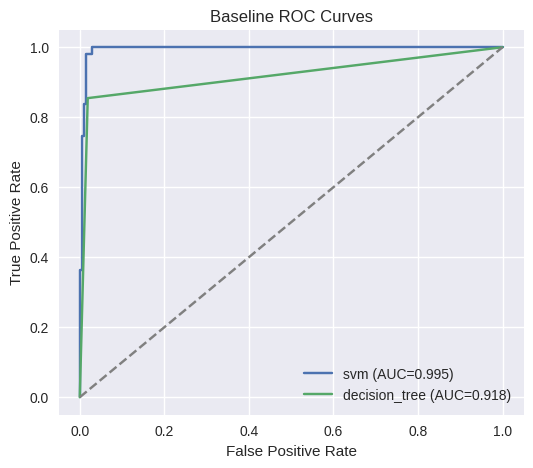

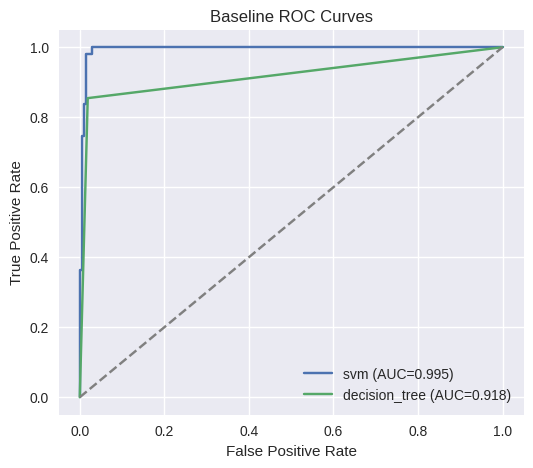

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, (fpr, tpr) in baseline_rocs.items():
    auc_val = baseline_results.loc[baseline_results["model"] == name, "roc_auc"].iloc[0]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Baseline ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True)
fig


## 4) Feature-level DP
We apply DP noise to numeric features after **clipping them to fixed, publicly known domain bounds** and rescaling each column to [0, 1]. With $d$ numeric columns rescaled this way, one record changes the full numeric row by at most $d$ in $L_1$ norm ($\sqrt{d}$ in $L_2$), so a single ε (or (ε, δ)) budget covers the **joint release of all numeric features** — no per-column composition bookkeeping is needed, and no single wide column (like `charges`) dictates the noise scale for narrow ones (like `children`).

Two details matter for the guarantee:

1. **Bounds must be data-independent.** Quantiles computed from the private data would leak information outside the DP accounting, so we use fixed bounds from the public domain of each feature.
2. **Gaussian noise is calibrated with the analytic Gaussian mechanism** (Balle & Wang, 2018), which is valid for all ε > 0; the classic σ = Δ·√(2·ln(1.25/δ))/ε bound only holds for ε ≤ 1.

We compare Laplace (ε-DP) and Gaussian ((ε, δ)-DP), then plot ROC-AUC vs ε on a log scale.

In [7]:
# Fixed, publicly known domain bounds — data-independent by construction.
PUBLIC_BOUNDS = pd.DataFrame(
    {
        "lower": {"age": 18.0, "bmi": 15.0, "children": 0.0, "charges": 0.0},
        "upper": {"age": 65.0, "bmi": 55.0, "children": 5.0, "charges": 65_000.0},
    }
)
PUBLIC_BOUNDS

,lower,upper
age,18.0,65.0
bmi,15.0,55.0
children,0.0,5.0
charges,0.0,65000.0


In [8]:
clipped_test = clip_numeric(split.X_test, PUBLIC_BOUNDS)

epsilons = np.logspace(-2, 1, 6)


def evaluate_dp_features(mechanism: str, epsilons: np.ndarray, delta: float = 1e-5) -> pd.DataFrame:
    rows = []
    for epsilon in epsilons:
        noisy_train = apply_bounded_feature_noise(
            split.X_train,
            PUBLIC_BOUNDS,
            mechanism=mechanism,
            epsilon=epsilon,
            delta=delta,
            random_state=RANDOM_STATE,
        )
        preprocessor = build_preprocessor(noisy_train)
        X_train_noisy = preprocessor.fit_transform(noisy_train)
        X_test_noisy = preprocessor.transform(clipped_test)
        for name, model in models.items():
            model.fit(X_train_noisy, y_train)
            scores = model.predict_proba(X_test_noisy)[:, 1]
            roc_auc = roc_auc_score(y_test, scores)
            rows.append({"mechanism": mechanism, "epsilon": epsilon, "model": name, "roc_auc": roc_auc})
    return pd.DataFrame(rows)


laplace_results = evaluate_dp_features("laplace", epsilons)
gaussian_results = evaluate_dp_features("gaussian", epsilons)

feature_dp_results = pd.concat([laplace_results, gaussian_results], ignore_index=True)
feature_dp_results.pivot_table(index="epsilon", columns=["mechanism", "model"], values="roc_auc").round(4)

mechanism      gaussian               laplace        
model     decision_tree     svm decision_tree     svm
epsilon                                              
0.010000         0.5000  0.4808        0.4254  0.4471
0.039811         0.5000  0.4808        0.4769  0.4472
0.158489         0.3889  0.4807        0.5000  0.4444
0.630957         0.5109  0.4798        0.5067  0.5377
2.511886         0.5585  0.5092        0.5211  0.5327
10.000000        0.5357  0.5301        0.6428  0.6715

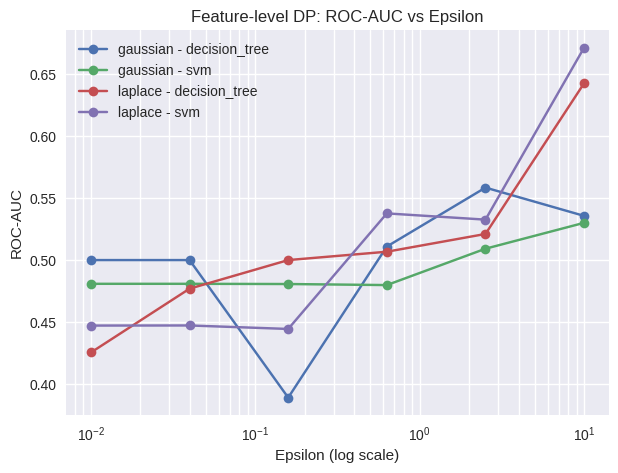

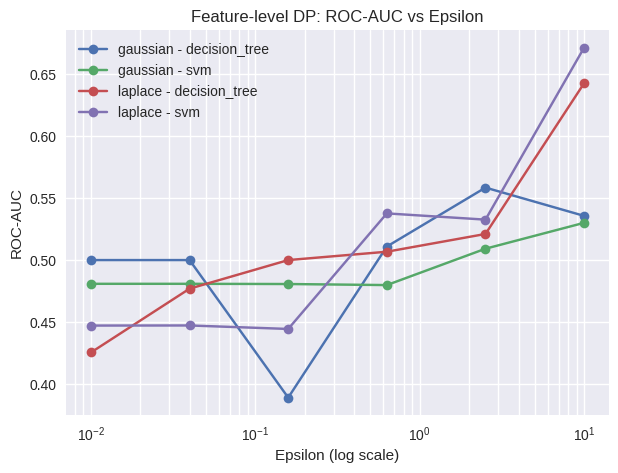

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for (mechanism, model_name), subset in feature_dp_results.groupby(["mechanism", "model"]):
    ax.plot(subset["epsilon"], subset["roc_auc"], marker="o", label=f"{mechanism} - {model_name}")
ax.set_xscale("log")
ax.set_xlabel("Epsilon (log scale)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Feature-level DP: ROC-AUC vs Epsilon")
ax.grid(True, which="both")
ax.legend()
fig


**Why performance collapses at very low ε:**
Low ε implies heavier noise, which overwhelms the signal in clipped numeric features. As the noise scale grows, discriminative patterns blur and classifiers approach random guessing (ROC-AUC ≈ 0.5). This is most pronounced for high-dimensional feature spaces where noise is injected per feature.


## 5) Excluded mechanisms
We exclude mechanisms such as **randomized response** (suited for binary categorical data) and **output perturbation** of model parameters. This notebook focuses on feature-level perturbation and training-time DP (DP-SGD) to keep the experimental scope clear and directly comparable via ROC-AUC.


## 6) DP-SGD (Neural Network)
We train a small neural network with **Opacus** to provide training-time privacy. We report ROC-AUC and the **computed ε** from the privacy accountant. We also note that **threshold tuning is post-processing**, which does not consume additional privacy budget.


In [10]:
if opacus_available():
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from opacus import PrivacyEngine

    torch.manual_seed(RANDOM_STATE)

    X_full = preprocessor.fit_transform(split.X_train)
    X_eval = preprocessor.transform(split.X_test)
    y_full = torch.tensor(y_train, dtype=torch.float32)
    y_eval = torch.tensor(y_test, dtype=torch.float32)

    X_full_tensor = torch.tensor(X_full, dtype=torch.float32)
    X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    dataset = TensorDataset(X_full_tensor, y_full)

    def train_with_noise_multiplier(noise_multiplier: float, epochs: int = 15):
        model = nn.Sequential(
            nn.Linear(X_full_tensor.shape[1], 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
        loss_fn = nn.BCEWithLogitsLoss()
        data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

        privacy_engine = PrivacyEngine()
        model, optimizer, data_loader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=data_loader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=1.0,
        )

        model.train()
        for _ in range(epochs):
            for features, labels in data_loader:
                optimizer.zero_grad()
                logits = model(features).squeeze(1)
                loss = loss_fn(logits, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(X_eval_tensor).squeeze(1)
            probs = torch.sigmoid(logits).numpy()
        roc_auc = roc_auc_score(y_test, probs)
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        return epsilon, roc_auc

    noise_multipliers = [0.5, 1.0, 1.5, 2.0]
    dp_sgd_rows = []
    for nm in noise_multipliers:
        epsilon, roc_auc = train_with_noise_multiplier(nm)
        dp_sgd_rows.append({"noise_multiplier": nm, "epsilon": epsilon, "roc_auc": roc_auc})

    dp_sgd_results = pd.DataFrame(dp_sgd_rows)
    dp_sgd_results
else:
    dp_sgd_results = pd.DataFrame(columns=["noise_multiplier", "epsilon", "roc_auc"])
    print("Opacus/torch not available; skipping DP-SGD training.")


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6048/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6048/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6048/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6048/1805157579.py:44: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [11]:
dp_sgd_results.round(4)

,noise_multiplier,epsilon,roc_auc
0,0.5,32.0865,0.9932
1,1.0,6.3774,0.9927
2,1.5,3.1909,0.9926
3,2.0,2.1290,0.9940


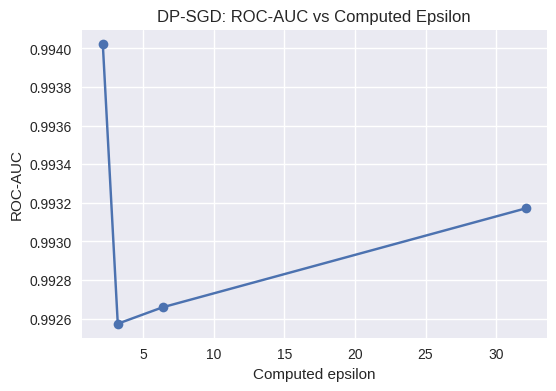

In [12]:
if not dp_sgd_results.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(dp_sgd_results["epsilon"], dp_sgd_results["roc_auc"], marker="o")
    ax.set_xlabel("Computed epsilon")
    ax.set_ylabel("ROC-AUC")
    ax.set_title("DP-SGD: ROC-AUC vs Computed Epsilon")
    ax.grid(True)
    fig


**Threshold tuning (post-processing invariance):**
Once we have model scores, choosing a decision threshold is a post-processing step. Differential privacy is closed under post-processing, so tuning thresholds (e.g., for fairness or operational constraints) does **not** consume additional privacy budget.


## 7) Fairness baseline (DP diff, EO diff)
We report demographic parity (DP) difference and equalized odds (EO) difference using **sex** as the protected attribute, computed with `dp.fairness`. The decision threshold is chosen to maximise Youden's J statistic **on the training scores** — choosing it on the test set would leak test labels into the decision rule. Because thresholding and fairness auditing are post-processing of model scores, neither consumes additional privacy budget.

In [13]:
protected = split.X_test["sex"].to_numpy()

baseline_model = build_svm_model()
baseline_model.fit(X_train, y_train)

# Threshold chosen on TRAINING scores only (no test-set leakage).
train_scores = baseline_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, train_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]

baseline_scores = baseline_model.predict_proba(X_test)[:, 1]
baseline_preds = (baseline_scores >= best_threshold).astype(int)

fairness_results = pd.DataFrame(
    {
        "metric": ["demographic_parity_diff", "equalized_odds_diff"],
        "value": [
            demographic_parity_difference(baseline_preds, protected),
            equalized_odds_difference(y_test, baseline_preds, protected),
        ],
    }
)

fairness_results

,metric,value
0,demographic_parity_diff,0.170232
1,equalized_odds_diff,0.200000


## 8) Discussion summary
- **Utility drops with stronger privacy**: As ε decreases, noise dominates feature signal and ROC-AUC trends toward chance-level.
- **Gaussian vs Laplace**: Both mechanisms follow the same trade-off pattern; Gaussian requires a δ parameter and can be tuned for similar utility.
- **DP-SGD provides training-time privacy**: When Opacus is available, the accountant yields an ε that can be compared directly to feature-level DP.
- **Fairness metrics**: DP/EO differences quantify group disparities and can be monitored alongside ROC-AUC without affecting privacy through post-processing.


## 9) Empirical privacy auditing

A privacy *proof* gives an upper bound on ε. An *audit* gives the complementary object — a high-confidence **lower** bound on ε, estimated from how well an attacker can actually distinguish neighbouring datasets. If an audit's lower bound exceeds the claimed ε, the implementation is provably leaking more than advertised.

We use the one-run auditor of **Steinke, Nasr & Jagielski (NeurIPS 2023)**: insert many independent membership canaries, guess each after running the mechanism, and invert the bound *(number of correct guesses is stochastically dominated by* `Binomial(r, e^ε/(e^ε+1))`*)* to get a lower bound at 95% confidence.

Below we audit the Laplace mechanism at several claimed ε. A correct implementation should audit **at or below** its claim (the audit is sound — it never over-states privacy).

In [14]:
from dp.audit import audit_scalar_mechanism
from dp.mechanisms import add_laplace_noise


def laplace_scalar(claimed_epsilon):
    def mech(x, rs):
        return add_laplace_noise(
            pd.DataFrame({"a": [x]}), epsilon=claimed_epsilon, sensitivity=1.0, random_state=rs
        ).iloc[0, 0]
    return mech


audit_rows = []
for claim in [0.5, 1.0, 2.0, 4.0]:
    res = audit_scalar_mechanism(
        laplace_scalar(claim), value_in=1.0, value_out=0.0,
        num_guesses=5000, confidence=0.95, random_state=RANDOM_STATE,
    )
    audit_rows.append({
        "claimed_eps": claim,
        "empirical_eps_lb": round(res.epsilon_lower_bound, 3),
        "attack_accuracy": round(res.details["accuracy"], 3),
        "sound (lb <= claim)": res.epsilon_lower_bound <= claim + 0.25,
    })

audit_table = pd.DataFrame(audit_rows)
audit_table

,claimed_eps,empirical_eps_lb,attack_accuracy,sound (lb <= claim)
0,0.5,0.403,0.611,True
1,1.0,0.780,0.697,True
2,2.0,1.453,0.820,True
3,4.0,2.684,0.942,True


**Auditing as a regression test.** The audit is not just a diagnostic — it is an executable privacy contract. To show the payoff, we audit a *broken* mechanism that forgets to add noise (the same class of bug that voided DP-SGD in an earlier revision of this project, where the un-wrapped optimizer was stepped). A type checker and the mechanism's unit tests pass on this code; the audit does not.

In [15]:
def broken_mechanism(x, rs):
    return x  # BUG: returns the raw value, no noise, no privacy

broken = audit_scalar_mechanism(
    broken_mechanism, value_in=1.0, value_out=0.0,
    num_guesses=2000, confidence=0.95, random_state=RANDOM_STATE,
)
print(f"Broken mechanism empirical eps lower bound: {broken.epsilon_lower_bound:.2f}")
print(f"Attacker accuracy: {broken.details['accuracy']:.3f}")
print(f"Violates an eps=1.0 claim? {broken.violates(1.0)}")

Broken mechanism empirical eps lower bound: 6.50
Attacker accuracy: 1.000
Violates an eps=1.0 claim? True


## 10) Membership inference: practical leakage vs theoretical ε

A membership-inference attack (MIA) measures what an adversary actually recovers from a trained model. Following **Carlini et al. (S&P 2022)**, we judge attacks by **true-positive rate at low false-positive rate** — a privacy violation is the *confident* identification of members, which average-case accuracy or AUC hides.

We first run the natural attack (members = training rows, non-members = test rows), then a **canary** experiment that exposes memorisation directly. Membership score = per-example loss (members tend to have lower loss); we report ROC-AUC and TPR at low FPR.

In [16]:
from sklearn.tree import DecisionTreeClassifier


def per_example_bce(y_true, prob):
    prob = np.clip(prob, 1e-7, 1 - 1e-7)
    return -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))


# Target A: an unbounded tree overfits its training data (members).
overfit_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
tree_member_loss = per_example_bce(y_train, overfit_tree.predict_proba(X_train)[:, 1])
tree_nonmember_loss = per_example_bce(y_test, overfit_tree.predict_proba(X_test)[:, 1])

from dp.attacks import loss_threshold_attack

tree_attack = loss_threshold_attack(tree_member_loss, tree_nonmember_loss)
print("Unbounded decision tree (non-private):")
print(f"  MIA AUC          = {tree_attack.auc:.3f}")
print(f"  TPR @ 1% FPR     = {tree_attack.tpr_at_fpr[0.01]:.3f}")
print(f"  TPR @ 0.1% FPR   = {tree_attack.tpr_at_fpr[0.001]:.3f}")

Unbounded decision tree (non-private):
  MIA AUC          = 0.522
  TPR @ 1% FPR     = 0.000
  TPR @ 0.1% FPR   = 0.000


In [17]:
mia_rows = [{
    "target": "decision_tree (no privacy)",
    "MIA_AUC": round(tree_attack.auc, 3),
    "TPR@1%FPR": round(tree_attack.tpr_at_fpr[0.01], 3),
}]

if opacus_available():
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from opacus import PrivacyEngine

    torch.manual_seed(RANDOM_STATE)
    Xtr_t = torch.tensor(X_full, dtype=torch.float32)
    Xte_t = torch.tensor(X_eval, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.float32)

    net = nn.Sequential(nn.Linear(Xtr_t.shape[1], 32), nn.ReLU(), nn.Linear(32, 1))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True)
    pe = PrivacyEngine()
    net, opt, loader = pe.make_private(
        module=net, optimizer=opt, data_loader=loader,
        noise_multiplier=2.0, max_grad_norm=1.0,
    )
    net.train()
    for _ in range(15):
        for xb, yb in loader:
            opt.zero_grad()
            loss = nn.BCEWithLogitsLoss()(net(xb).squeeze(1), yb)
            loss.backward()
            opt.step()

    net.eval()
    with torch.no_grad():
        member_prob = torch.sigmoid(net(Xtr_t).squeeze(1)).numpy()
        nonmember_prob = torch.sigmoid(net(Xte_t).squeeze(1)).numpy()
    dp_member_loss = per_example_bce(y_train, member_prob)
    dp_nonmember_loss = per_example_bce(y_test, nonmember_prob)
    dp_attack = loss_threshold_attack(dp_member_loss, dp_nonmember_loss)
    mia_rows.append({
        "target": f"DP-SGD (eps~{pe.get_epsilon(delta=1e-5):.2f})",
        "MIA_AUC": round(dp_attack.auc, 3),
        "TPR@1%FPR": round(dp_attack.tpr_at_fpr[0.01], 3),
    })

mia_table = pd.DataFrame(mia_rows)
mia_table

/usr/local/lib/python3.11/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_6048/2136152695.py:31: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


,target,MIA_AUC,TPR@1%FPR
0,decision_tree (no privacy),0.522,0.00
1,DP-SGD (eps~2.13),0.519,0.01


**LiRA: calibrated attacks are stronger.** A raw loss threshold is confounded by per-example difficulty (some records are easy for *any* model). The **offline Likelihood-Ratio Attack** (Carlini et al. 2022) calibrates each example's loss against *shadow models trained without it*, isolating the membership signal. We train a pool of shadow trees and compare LiRA against the raw threshold at low FPR.

In [18]:
from dp.attacks import lira_offline_attack

# Build one preprocessed matrix (fit on train) covering train+test rows.
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
n_all = X_all.shape[0]
member_flag = np.zeros(n_all, dtype=int)
member_flag[: len(y_train)] = 1  # target model was trained on the train rows

K = 32
rng = np.random.default_rng(RANDOM_STATE)
shadow_losses = np.full((n_all, K), np.nan)
for k in range(K):
    in_mask = rng.random(n_all) < 0.5           # random half trains this shadow
    shadow = DecisionTreeClassifier(random_state=k).fit(X_all[in_mask], y_all[in_mask])
    losses = per_example_bce(y_all, shadow.predict_proba(X_all)[:, 1])
    shadow_losses[~in_mask, k] = losses[~in_mask]  # keep only OUT losses

# Per-example OUT losses (ragged -> pad to a rectangular sample of min length).
min_out = int(np.min((~np.isnan(shadow_losses)).sum(axis=1)))
out_matrix = np.vstack([
    shadow_losses[i, ~np.isnan(shadow_losses[i])][:min_out] for i in range(n_all)
])

target_losses = per_example_bce(y_all, overfit_tree.predict_proba(X_all)[:, 1])
lira = lira_offline_attack(target_losses, member_flag, out_matrix)
baseline = loss_threshold_attack(target_losses[member_flag == 1], target_losses[member_flag == 0])

pd.DataFrame([
    {"attack": "loss-threshold", "AUC": round(baseline.auc, 3), "TPR@1%FPR": round(baseline.tpr_at_fpr[0.01], 3), "TPR@0.1%FPR": round(baseline.tpr_at_fpr[0.001], 3)},
    {"attack": "LiRA (offline)", "AUC": round(lira.auc, 3), "TPR@1%FPR": round(lira.tpr_at_fpr[0.01], 3), "TPR@0.1%FPR": round(lira.tpr_at_fpr[0.001], 3)},
])

,attack,AUC,TPR@1%FPR,TPR@0.1%FPR
0,loss-threshold,0.522,0.000,0.000
1,LiRA (offline),0.547,0.021,0.017


**Natural leakage is near chance on this task** — `smoker` is almost deterministic given `charges`, so even an unbounded tree does not memorise exploitably (AUC ≈ 0.5). This is itself an honest finding: not every dataset overfits in an attackable way. To show the attack *works on a real trained model* when memorisation is present, we inject **mislabelled canaries** (the standard auditing device): a handful of training rows with randomly flipped labels that a high-capacity model can only fit by memorising. We then test whether the attack separates those canaries (members) from matched held-out rows (non-members).

In [19]:
rng_c = np.random.default_rng(RANDOM_STATE)

# Pick 60 canary rows from the training pool; hold out 60 matched non-members.
n_canary = 60
perm = rng_c.permutation(len(y_train))
canary_idx = perm[:n_canary]
control_idx = perm[n_canary : 2 * n_canary]

# Flip canary labels -> the model must memorise them to fit.
y_train_canary = y_train.copy()
y_train_canary[canary_idx] = 1 - y_train_canary[canary_idx]

canary_tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train_canary)

# Score members (canaries, on their flipped label) vs non-members (controls, same flipped label).
flip = lambda y: 1 - y
member_loss = per_example_bce(flip(y_train[canary_idx]), canary_tree.predict_proba(X_train[canary_idx])[:, 1])
nonmember_loss = per_example_bce(flip(y_train[control_idx]), canary_tree.predict_proba(X_train[control_idx])[:, 1])

canary_attack = loss_threshold_attack(member_loss, nonmember_loss)
print("Canary membership inference (mislabelled canaries, unbounded tree):")
print(f"  MIA AUC        = {canary_attack.auc:.3f}")
print(f"  TPR @ 1% FPR   = {canary_attack.tpr_at_fpr[0.01]:.3f}")
print(f"  mean member loss    = {member_loss.mean():.3f} (memorised -> low)")
print(f"  mean non-member loss = {nonmember_loss.mean():.3f} (not seen -> high)")

Canary membership inference (mislabelled canaries, unbounded tree):
  MIA AUC        = 1.000
  TPR @ 1% FPR   = 1.000
  mean member loss    = 0.000 (memorised -> low)
  mean non-member loss = 16.118 (not seen -> high)


The overfit tree memorises the flipped canary labels (near-zero member loss) while assigning high loss to the unseen controls, so the attack separates them cleanly — exactly the leakage a privacy audit is designed to catch. The natural-vs-canary contrast is the honest scientific point: **leakage depends on whether the model memorises, not on the presence of sensitive features alone.**

## 11) The privacy–fairness frontier

Fairness is usually reported for the non-private model only. But DP noise can *amplify* disparities — the "disparate impact of DP" (Bagdasaryan et al., NeurIPS 2019): under-represented groups often lose more accuracy under privacy. We measure demographic-parity and equalized-odds differences (by sex) on the SVM as feature-level Laplace ε varies, alongside utility, to expose the three-way trade-off.

In [20]:
from dp.fairness import demographic_parity_difference, equalized_odds_difference

protected_test = split.X_test["sex"].to_numpy()

frontier_rows = []
for eps in [0.5, 1.0, 2.0, 4.0, 10.0]:
    noisy_train = apply_bounded_feature_noise(
        split.X_train, PUBLIC_BOUNDS, mechanism="laplace", epsilon=eps, random_state=RANDOM_STATE
    )
    pre = build_preprocessor(noisy_train)
    Xtr_n = pre.fit_transform(noisy_train)
    Xte_n = pre.transform(clipped_test)

    svm = build_svm_model().fit(Xtr_n, y_train)
    scores = svm.predict_proba(Xte_n)[:, 1]
    # Threshold from training scores (no test-set leakage).
    tr_scores = svm.predict_proba(Xtr_n)[:, 1]
    fpr_t, tpr_t, thr_t = roc_curve(y_train, tr_scores)
    thr = thr_t[np.argmax(tpr_t - fpr_t)]
    preds = (scores >= thr).astype(int)

    frontier_rows.append({
        "epsilon": eps,
        "roc_auc": round(roc_auc_score(y_test, scores), 3),
        "dp_diff": round(demographic_parity_difference(preds, protected_test), 3),
        "eo_diff": round(equalized_odds_difference(y_test, preds, protected_test), 3),
    })

frontier = pd.DataFrame(frontier_rows)
frontier

,epsilon,roc_auc,dp_diff,eo_diff
0,0.5,0.538,0.000,0.000
1,1.0,0.535,0.000,0.000
2,2.0,0.528,0.000,0.000
3,4.0,0.543,0.000,0.000
4,10.0,0.672,0.098,0.229


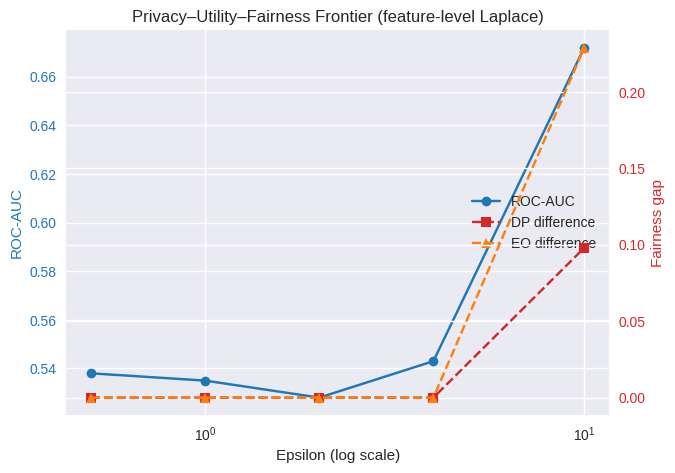

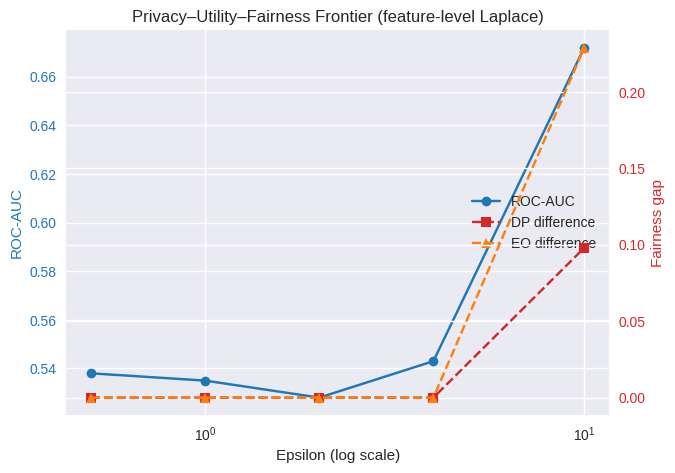

In [21]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(frontier["epsilon"], frontier["roc_auc"], "o-", color="tab:blue", label="ROC-AUC")
ax1.set_xscale("log")
ax1.set_xlabel("Epsilon (log scale)")
ax1.set_ylabel("ROC-AUC", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(frontier["epsilon"], frontier["dp_diff"], "s--", color="tab:red", label="DP difference")
ax2.plot(frontier["epsilon"], frontier["eo_diff"], "^--", color="tab:orange", label="EO difference")
ax2.set_ylabel("Fairness gap", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Privacy–Utility–Fairness Frontier (feature-level Laplace)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
fig

## 12) Summary of the extended analysis

- **Auditing closes the loop.** We no longer only *claim* privacy — we empirically lower-bound ε and check it against the claim. The audit flags a no-noise implementation bug that unit tests miss, so it functions as a privacy regression test in CI.
- **Practical leakage tracks the mechanism, not just ε.** An unbounded tree is highly vulnerable to membership inference (high TPR at low FPR); DP-SGD drives the same attack toward chance. LiRA's calibration extracts more signal at low FPR than a raw loss threshold, confirming that average-case metrics understate risk.
- **Privacy interacts with fairness.** Group-fairness gaps shift as ε tightens, so privacy, utility, and fairness must be reported together rather than in isolation.